In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
birds_df = pd.read_csv(
    "../cleaned_data/birds_cleaned.csv"
)

birds_df.head()

,AOU_Code,AcceptedTSN,Admin_Sheet,Admin_Unit_Code,Common_Name,Date,Distance,Disturbance,End_Time,Flyover_Observed,Habitat,Humidity,ID_Method,Initial_Three_Min_Cnt,Interval_Length,Location_Type,NPSTaxonCode,Observer,PIF_Watchlist_Status,Plot_Name,Regional_Stewardship_Status,Scientific_Name,Sex,Site_Name,Sky,Start_Time,Temperature,Visit,Wind,Year,Month,Month_Name,Quarter,Season
0,EATO,179276.0,ANTI,ANTI,Eastern Towhee,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,True,0-2.5 min,Forest,83803.0,Elizabeth Oswald,False,ANTI-0036,True,Pipilo erythrophthalmus,Undetermined,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
1,WBNU,178775.0,ANTI,ANTI,White-breasted Nuthatch,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,True,0-2.5 min,Forest,90935.0,Elizabeth Oswald,False,ANTI-0036,False,Sitta carolinensis,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
2,RBWO,178195.0,ANTI,ANTI,Red-bellied Woodpecker,2018-05-22,50 - 100 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,False,2.5 - 5 min,Forest,84865.0,Elizabeth Oswald,False,ANTI-0036,False,Melanerpes carolinus,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
3,OROR,179064.0,ANTI,ANTI,Orchard Oriole,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,False,2.5 - 5 min,Forest,93634.0,Elizabeth Oswald,False,ANTI-0036,False,Icterus spurius,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
4,NOMO,178620.0,ANTI,ANTI,Northern Mockingbird,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Visualization,False,2.5 - 5 min,Forest,88394.0,Elizabeth Oswald,False,ANTI-0036,False,Mimus polyglottos,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring


In [3]:
habitat_counts = (
    birds_df["Habitat"]
    .value_counts()
    .reset_index()
)

habitat_counts.columns = [
    "Habitat",
    "Observation_Count"
]

habitat_counts

,Habitat,Observation_Count
0,Forest,8546
1,Grassland,6826


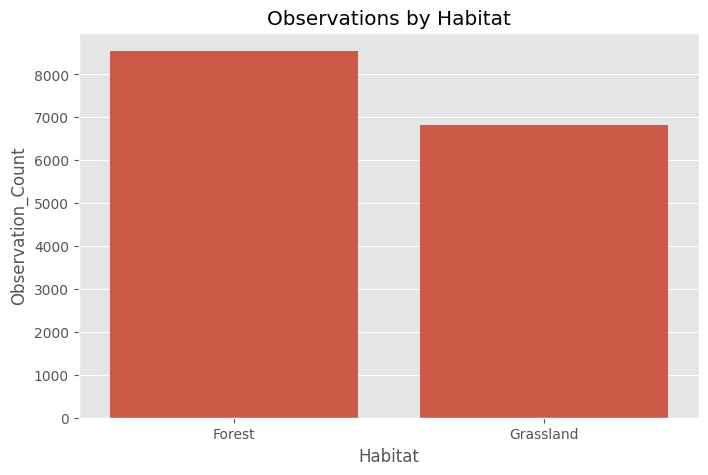

In [4]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=habitat_counts,
    x="Habitat",
    y="Observation_Count"
)

plt.title(
    "Observations by Habitat"
)

plt.show()

In [16]:

fig = px.pie(
    habitat_counts,
    names="Habitat",
    values="Observation_Count",
    title="Habitat Distribution"
)

fig.show()



plt.savefig(
    "../images/spatial/habitat_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [6]:
admin_counts = (
    birds_df["Admin_Unit_Code"]
    .value_counts()
    .reset_index()
)

admin_counts.columns = [
    "Admin_Unit",
    "Observation_Count"
]

admin_counts.head(15)

,Admin_Unit,Observation_Count
0,ANTI,3463
1,MONO,2522
2,PRWI,2463
3,CHOH,2202
4,MANA,1901
5,CATO,805
6,NACE,684
7,HAFE,530
8,GWMP,386
9,ROCR,289


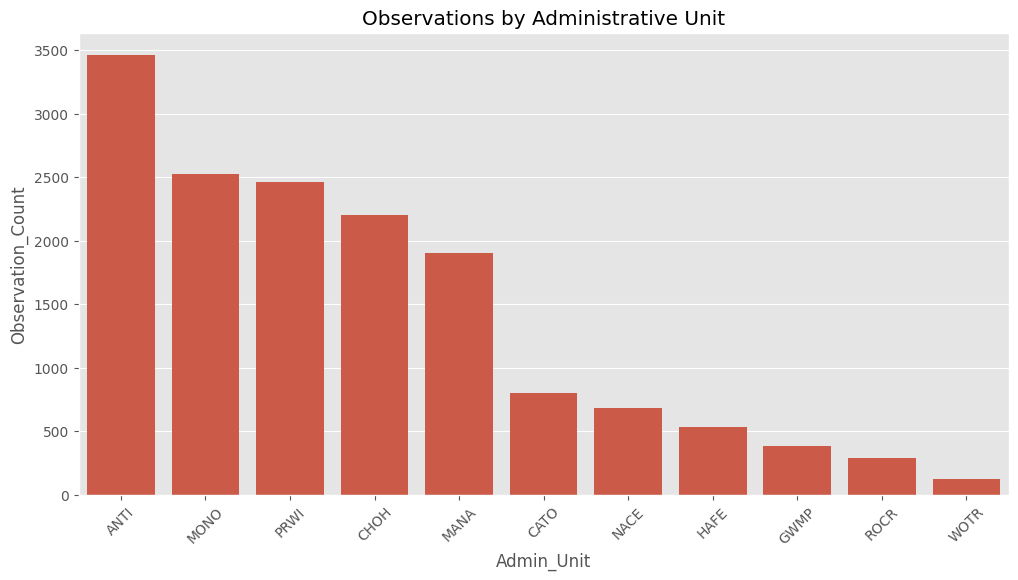

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=admin_counts,
    x="Admin_Unit",
    y="Observation_Count"
)

plt.title(
    "Observations by Administrative Unit"
)

plt.xticks(rotation=45)

plt.show()

plt.savefig(
    "../images/spatial/admin_unit_observations.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [8]:
fig = px.bar(
    admin_counts,
    x="Admin_Unit",
    y="Observation_Count",
    title="Administrative Unit Observation Counts"
)

fig.show()

In [9]:
species_hotspots = (
    birds_df.groupby("Admin_Unit_Code")
    ["Scientific_Name"]
    .nunique()
    .reset_index()
)

species_hotspots.columns = [
    "Admin_Unit",
    "Unique_Species"
]

species_hotspots = (
    species_hotspots
    .sort_values(
        by="Unique_Species",
        ascending=False
    )
)

species_hotspots.head(10)

,Admin_Unit,Unique_Species
6,MONO,100
5,MANA,81
0,ANTI,81
2,CHOH,80
7,NACE,66
4,HAFE,55
8,PRWI,54
3,GWMP,49
1,CATO,46
9,ROCR,45


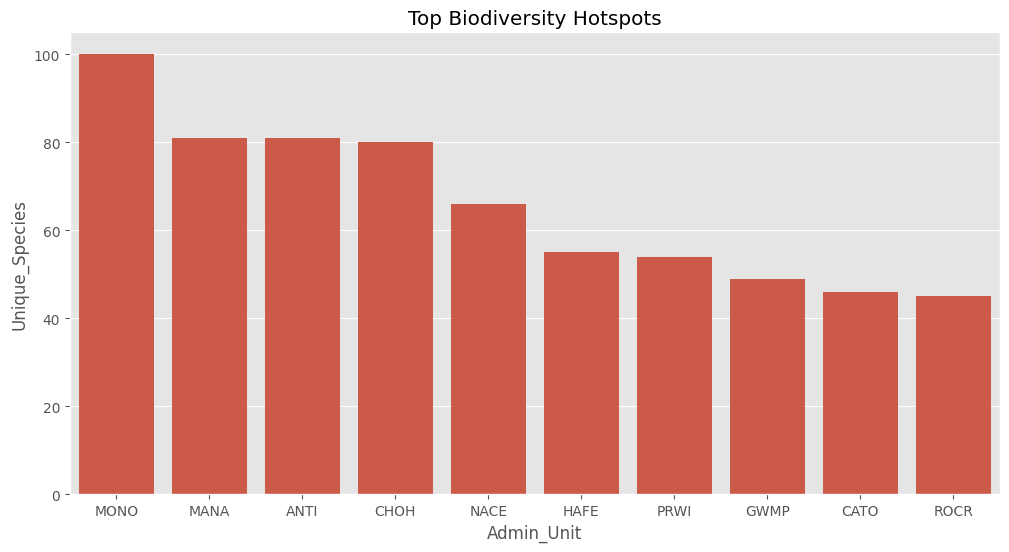

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=species_hotspots.head(10),
    x="Admin_Unit",
    y="Unique_Species"
)

plt.title(
    "Top Biodiversity Hotspots"
)

plt.show()

plt.savefig(
    "../images/spatial/top_biodiversity_hotspots.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [11]:
top_plots = (
    birds_df["Plot_Name"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_plots.columns = [
    "Plot_Name",
    "Observation_Count"
]

top_plots

,Plot_Name,Observation_Count
0,ANTI-0163,54
1,ANTI-0028,52
2,HAFE-0067,52
3,MANA-0048,50
4,ANTI-0016,49
5,ANTI-0034,48
6,ANTI-0161,48
7,ANTI-0184,48
8,MONO-0037,48
9,MONO-0057,48


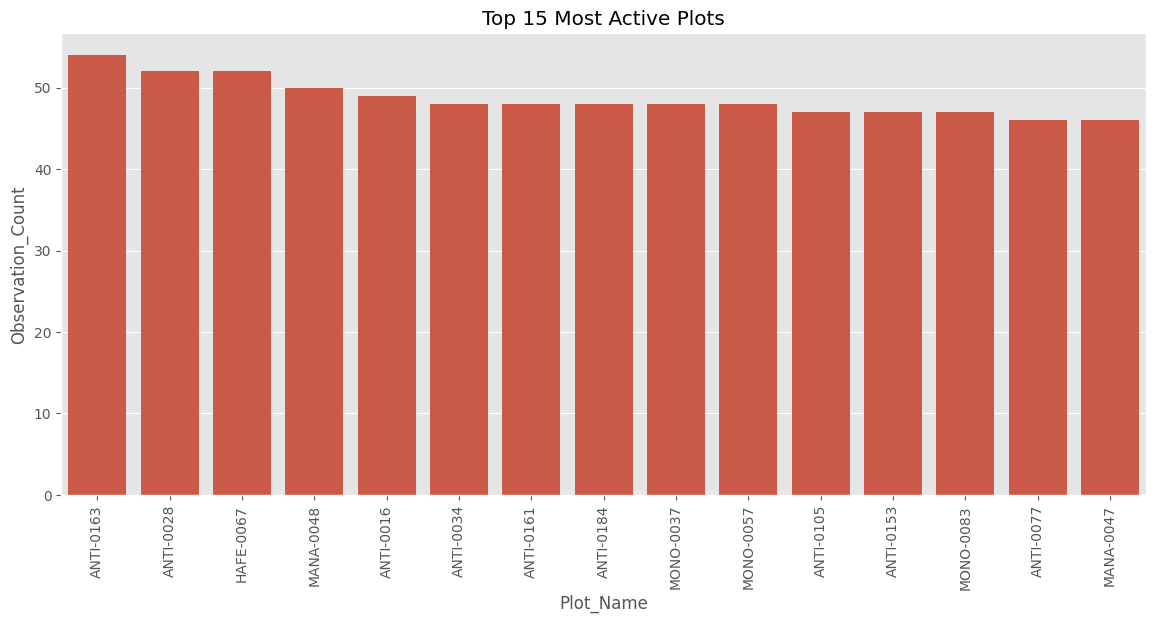

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_plots,
    x="Plot_Name",
    y="Observation_Count"
)

plt.xticks(rotation=90)

plt.title(
    "Top 15 Most Active Plots"
)

plt.show()

plt.savefig(
    "../images/spatial/top_15_most_active_plots.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [13]:
diversity = (
    birds_df.groupby("Habitat")
    ["Scientific_Name"]
    .nunique()
    .reset_index()
)

diversity.columns = [
    "Habitat",
    "Unique_Species"
]

diversity

,Habitat,Unique_Species
0,Forest,108
1,Grassland,107


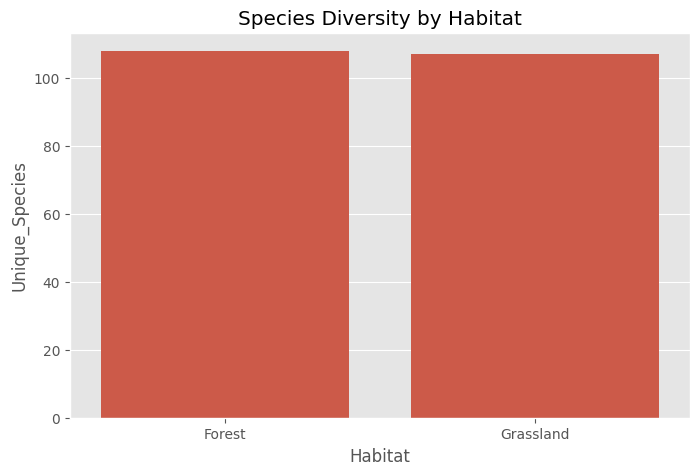

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=diversity,
    x="Habitat",
    y="Unique_Species"
)

plt.title(
    "Species Diversity by Habitat"
)

plt.show()

## Spatial Analysis Findings

### 1. Habitat Distribution
- Forest habitat recorded the highest number of observations.
- Forest: 8,546 observations (55.6%)
- Grassland: 6,826 observations (44.4%)

### 2. Administrative Unit Analysis
- ANTI (Antietam National Battlefield) recorded the highest number of observations with 3,463 records.
- MONO and PRWI were the second and third most active administrative units.
- WOTR recorded the lowest number of observations (127).

### 3. Biodiversity Hotspots
- MONO was identified as the strongest biodiversity hotspot with 100 unique bird species.
- MANA and ANTI recorded 81 unique species each.
- CHOH recorded 80 unique species.

### 4. Plot-Level Analysis
- Plot ANTI-0163 was the most active plot with 54 observations.
- Several ANTI plots appeared among the top observed locations, indicating high bird activity in that region.

### 5. Habitat Diversity
- Forest habitat contained 108 unique species.
- Grassland habitat contained 107 unique species.
- Species diversity is nearly identical across both habitats.
- Forest habitat shows slightly higher biodiversity.

Forest Observations      : 8546
Grassland Observations   : 6826

Forest Species Diversity : 108
Grassland Species Diversity : 107

Forest habitat has more bird observations,
but species diversity is almost identical.

This suggests grasslands support nearly the
same ecological richness despite fewer sightings.

Therefore grassland conservation is equally important.